### Parametres

In [34]:
from functools import partial
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import torch

import vt_all_solvers_wrapper as vt
import dataset
import utils
import models.mlp as mlp_module
import models.fno as fno_module
import models.deep as deep_module

importlib.reload(vt)
importlib.reload(dataset)
importlib.reload(utils)
importlib.reload(mlp_module)
importlib.reload(fno_module)
importlib.reload(deep_module)

import base_range_library 
importlib.reload(base_range_library)
from base_range_library import range_library

from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader
from utils import (
    DEFAULT_VALIDATION_METRICS,
    TrainConfig,
    fit,
    make_optimizer,
    mse_loss,
    plot_history,
)
from losses import UniversalTransferFunctionLoss
from models.mlp import ProfileMLP, webster_mlp_batch_to_xy
from models.fno import TransferFunctionFNO, webster_fno_batch_to_xy
from models.deep import (
    TransferFunctionDeepONet,
    TransferFunctionDynamicDeepONet,
    TransferFunctionDeformableDeepONet,
    webster_deeponet_batch_to_xy,
)

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
sections = 100
n_profile_points = 128
n_frequencies = 256

steps_per_epoch = 10
val_steps = 10
epochs = 20

# Change this to inspect another channel inside the validation batch.
preview_sample_idx = 0

mlp_checkpoint_name = "mlp_db"
fno_checkpoint_name = "fno_db"
deeponet_checkpoint_name = "deeponet_db"
dynamic_deeponet_checkpoint_name = "dynamic_deeponet_db"
deformable_deeponet_checkpoint_name = "deformable_deeponet_db"

loss_name = "transfer_db"  # "mse" or "transfer_db"
transfer_loss_db_kwargs = {
    "output_type": "db",
    "db_weight": 1.0,
    "magnitude_weight": 0.1,
    "db_derivative_weight": 0.02,
    "peak_weight": 0.0,
    "complex_weight": 0.0,
    "complex_derivative_weight": 0.0,
    "phase_weight": 0.0,
    "db_error_scale": 10.0,
    "db_derivative_scale": 0.01,
    "peak_temperature_db": 3.0,
    "phase_dynamic_range_db": 40.0,
    "min_db": -100.0,
    "eps": 1e-8,
}

solver_config = vt.SolverConfig(
    solver="cone",
    sections=sections,
    points=n_frequencies,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
)

train_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=1,
)

val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=100_000,
    max_samples=batch_size * val_steps,
)

print("device:", device)


device: cuda


In [36]:
train_loader = make_streaming_dataloader(
    train_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

val_loader = make_streaming_dataloader(
    val_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

In [37]:
mlp_batch_to_xy = partial(
    webster_mlp_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
    include_x=True,
)

fno_batch_to_xy = partial(
    webster_fno_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
)

deeponet_batch_to_xy = partial(
    webster_deeponet_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
    frequency_min_hz=solver_config.f_min_hz,
    frequency_max_hz=solver_config.f_max_hz,
)

In [38]:
validation_metrics = list(DEFAULT_VALIDATION_METRICS.keys())

transfer_loss_db = UniversalTransferFunctionLoss(**transfer_loss_db_kwargs)

loss_registry = {
    "mse": mse_loss,
    "transfer_db": transfer_loss_db,
}

criterion = loss_registry[loss_name]

print("loss:", criterion)
print("validation metrics:", validation_metrics)

loss: UniversalTransferFunctionLoss()
validation metrics: ['mae', 'rmse', 'rel_l2', 'magnitude_mae_db', 'magnitude_rmse_db', 'magnitude_max_abs_error_db', 'relative_derivative_l2', 'dominant_peak_frequency_mae_hz', 'dominant_peak_level_mae_db', 'dominant_notch_frequency_mae_hz', 'dominant_notch_level_mae_db', 'relative_complex_l2_percent', 'phase_mae_degrees']


In [39]:
def validation_preview_batch():
    return next(iter(val_loader))


def predict_on_batch(model, batch_to_xy, batch):
    prediction, target = utils.predict(
        model,
        [batch],
        batch_to_xy=batch_to_xy,
        device=device,
        show_progress=False,
    )
    return prediction, target


def batch_geometry_to_explicit(batch, sample_idx):
    if "geometry" not in batch:
        raise KeyError("batch does not contain geometry")

    geom = batch["geometry"]
    n = int(geom["node_count"][sample_idx])

    return vt.ExplicitGeometry(
        x_m=geom["x_m"][sample_idx, :n].detach().cpu().tolist(),
        area_m2=geom["area_m2"][sample_idx, :n].detach().cpu().tolist(),
    )


def plot_batch_geometry(batch, sample_idx, ax=None, *, title="Channel geometry"):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3.5))

    geometry = batch_geometry_to_explicit(batch, sample_idx)
    vt.plot_geometry(
        geometry,
        mode="symmetric",
        equal_aspect=False,
        linewidth=1.5,
        ax=ax,
        title=title,
    )
    ax.grid(True, alpha=0.25)
    return ax


def plot_model_prediction_on_channel(
    batch,
    prediction,
    target,
    model_label,
    *,
    sample_idx=preview_sample_idx,
):
    if sample_idx < 0 or sample_idx >= target.shape[0]:
        raise IndexError(
            f"sample_idx={sample_idx} is outside validation batch size {target.shape[0]}"
        )

    freq = batch["frequencies_hz"][sample_idx].detach().cpu()
    pred = prediction[sample_idx]
    y = target[sample_idx]

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    plot_batch_geometry(
        batch,
        sample_idx,
        axes[0],
        title=f"Validation sample {sample_idx}",
    )

    axes[1].plot(freq, y, label="target dB", linewidth=2.0, color="black")
    axes[1].plot(freq, pred, label=model_label, linewidth=1.8)
    axes[1].set_xlabel("Frequency, Hz")
    axes[1].set_ylabel("Transfer function, dB")
    axes[1].set_title(model_label)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    mae = torch.mean(torch.abs(pred - y)).item()
    rmse = torch.sqrt(torch.mean((pred - y) ** 2)).item()
    print(f"{model_label} MAE dB:  {mae:.4f}")
    print(f"{model_label} RMSE dB: {rmse:.4f}")


def plot_single_model_preview(model, batch_to_xy, model_label, *, sample_idx=preview_sample_idx):
    batch = validation_preview_batch()
    prediction, target = predict_on_batch(model, batch_to_xy, batch)
    plot_model_prediction_on_channel(
        batch,
        prediction,
        target,
        model_label,
        sample_idx=sample_idx,
    )

### MLP

In [ ]:
mlp = ProfileMLP(
    n_profile_points=n_profile_points,
    in_channels=2,  # log(area), x
    n_frequencies=n_frequencies,
    hidden_dim=512,
    depth=4,
    dropout=0.05,
    out_channels=1,
).to(device)

mlp_optimizer = make_optimizer(
    mlp,
    lr=1e-3,
    weight_decay=1e-4,
)

mlp_history = fit(
    mlp,
    mlp_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=mlp_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=mlp_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(mlp_history)


#### Проверка MLP на одном канале

In [ ]:
plot_single_model_preview(
    mlp,
    mlp_batch_to_xy,
    "MLP",
    sample_idx=preview_sample_idx,
)

### FNO

In [ ]:
fno = TransferFunctionFNO(
    n_modes=32,
    hidden_channels=96,
    latent_dim=256,
    pooling_bins=16,
    frequency_bands=16,
    out_channels=1,
).to(device)

fno_optimizer = make_optimizer(
    fno,
    lr=5e-4,
    weight_decay=1e-4,
)

fno_history = fit(
    fno,
    fno_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=fno_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=fno_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(fno_history)

#### Проверка FNO на одном канале

In [ ]:
plot_single_model_preview(
    fno,
    fno_batch_to_xy,
    "FNO",
    sample_idx=preview_sample_idx,
)

### DeepONet

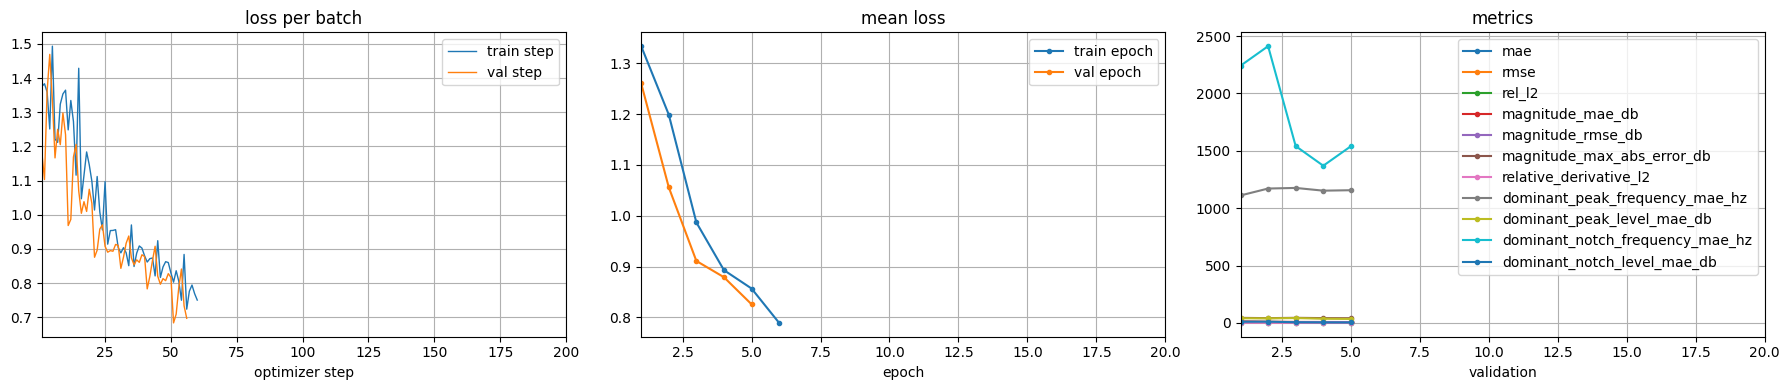

In [ ]:
deeponet = TransferFunctionDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
).to(device)

deeponet_optimizer = make_optimizer(
    deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

deeponet_history = fit(
    deeponet,
    deeponet_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(deeponet_history)

#### Проверка DeepONet на одном канале

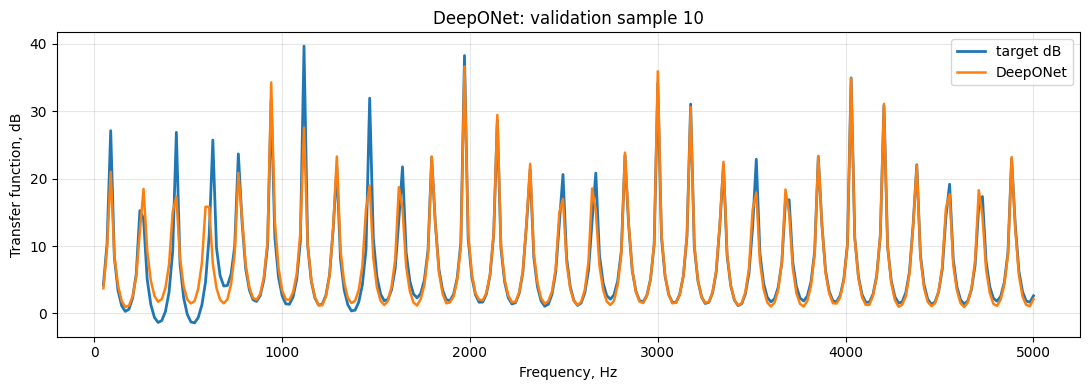

DeepONet preview MAE dB:  1.2348
DeepONet preview RMSE dB: 2.4715


In [ ]:
plot_single_model_preview(
    deeponet,
    deeponet_batch_to_xy,
    "DeepONet",
    sample_idx=10,
)

### Dynamic DeepONet


In [ ]:
# Cell 9.2: train Dynamic DeepONet

dynamic_deeponet = TransferFunctionDynamicDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
    n_experts=4,
    routing_hidden_dim=32,
    temperature=1.0,
).to(device)

dynamic_deeponet_optimizer = make_optimizer(
    dynamic_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

dynamic_deeponet_history = fit(
    dynamic_deeponet,
    dynamic_deeponet_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=dynamic_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(dynamic_deeponet_history)


#### Проверка Dynamic DeepONet на одном канале


In [ ]:
# Cell 9.3: check Dynamic DeepONet on one validation channel

plot_single_model_preview(
    dynamic_deeponet,
    deeponet_batch_to_xy,
    "Dynamic DeepONet",
    sample_idx=preview_sample_idx,
)


### Deformable DeepONet


In [ ]:
# Cell 9.4: train Deformable DeepONet

deformable_deeponet = TransferFunctionDeformableDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
    max_offset=2.0,
    offset_hidden_channels=32,
).to(device)

deformable_deeponet_optimizer = make_optimizer(
    deformable_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

deformable_deeponet_history = fit(
    deformable_deeponet,
    deformable_deeponet_optimizer,
    train_loader,
    val_loader,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=50,
        grad_clip_norm=None,
        checkpoint_name=deformable_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
    ),
)

plot_history(deformable_deeponet_history)


#### Проверка Deformable DeepONet на одном канале


In [ ]:
# Cell 9.5: check Deformable DeepONet on one validation channel

plot_single_model_preview(
    deformable_deeponet,
    deeponet_batch_to_xy,
    "Deformable DeepONet",
    sample_idx=preview_sample_idx,
)


### Дообучение


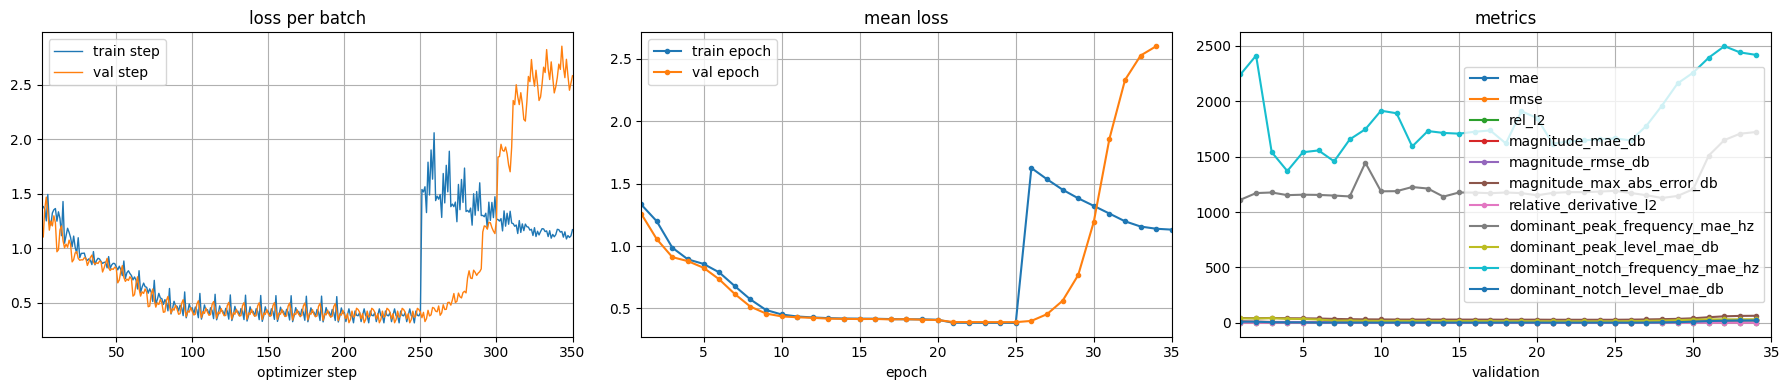

epoch 035/35 | train=1.13158 | val=2.62675 | lr=5e-06


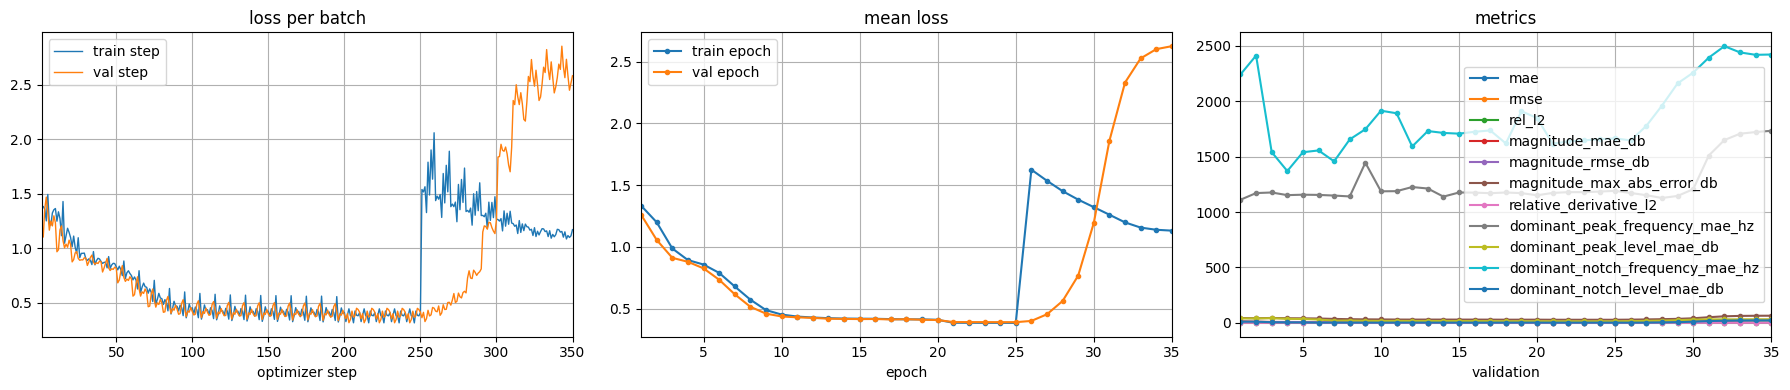

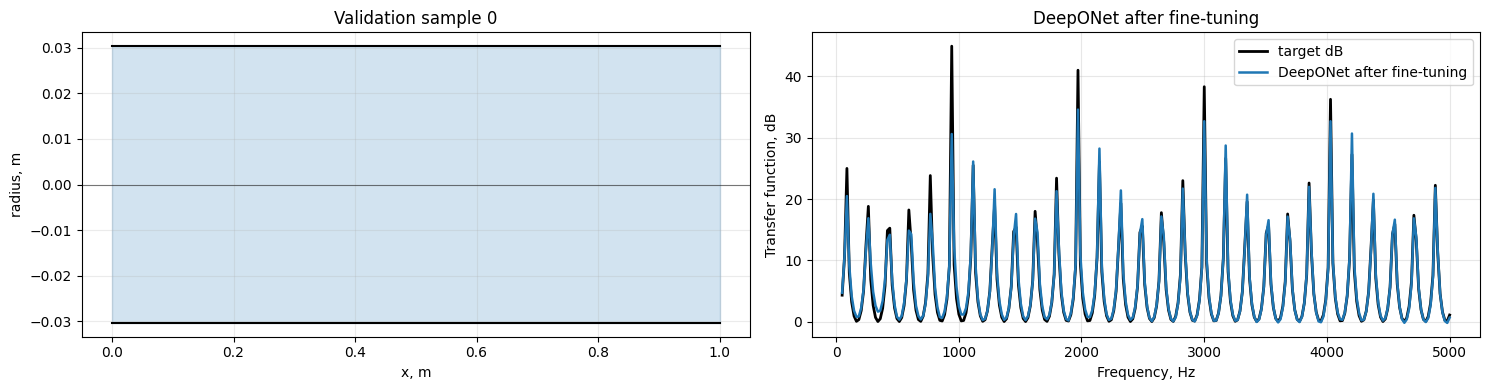

DeepONet after fine-tuning MAE dB:  0.6635
DeepONet after fine-tuning RMSE dB: 1.4082


In [27]:
importlib.reload(utils)

finetune_model_name = "deeponet"  # "mlp", "fno", "deeponet", "dynamic_deeponet", or "deformable_deeponet"
finetune_epochs = 10
finetune_steps_per_epoch = steps_per_epoch
finetune_val_steps = val_steps
finetune_batch_size = batch_size
finetune_lr_scale = 1e-2
finetune_resume_optimizer = True
finetune_live_plot_every_steps = 50
finetune_save_every_steps = None
finetune_checkpoint_suffix = "_finetuned_"  # use "_finetuned" to keep the old best checkpoint untouched

mlp_checkpoint_name = "mlp_db"
fno_checkpoint_name = "fno_db_finetuned"
deeponet_checkpoint_name = "deeponet_db_finetuned"
dynamic_deeponet_checkpoint_name = "dynamic_deeponet_db"
deformable_deeponet_checkpoint_name = "deformable_deeponet_db"

active_library_kinds = [name for name in range_library.keys() if name != "random"]
print("active library geometry kinds:", active_library_kinds)

all_library_train_config = StreamingGeometryDatasetConfig(
    geometry_kind="tube_with_hole",  # random means: sample from every active key in range_library
    solver_config=solver_config,
    target_mode="db",
    seed=1_000_000,
)

all_library_val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=2_000_000,
    max_samples=finetune_batch_size * finetune_val_steps,
)

all_library_train_loader = make_streaming_dataloader(
    all_library_train_config,
    range_library,
    batch_size=finetune_batch_size,
    num_workers=0,
)

all_library_val_loader = make_streaming_dataloader(
    all_library_val_config,
    range_library,
    batch_size=finetune_batch_size,
    num_workers=0,
)


def finetune_checkpoint_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        return checkpoint["model_state"]
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint["state_dict"]
    return checkpoint


def make_mlp_for_finetune():
    return ProfileMLP(
        n_profile_points=n_profile_points,
        in_channels=2,
        n_frequencies=n_frequencies,
        hidden_dim=512,
        depth=4,
        dropout=0.05,
        out_channels=1,
    )


def make_fno_for_finetune():
    return TransferFunctionFNO(
        n_modes=32,
        hidden_channels=96,
        latent_dim=256,
        pooling_bins=16,
        frequency_bands=16,
        out_channels=1,
    )


def make_deeponet_for_finetune():
    return TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
    )


def make_dynamic_deeponet_for_finetune():
    return TransferFunctionDynamicDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
    )


def make_deformable_deeponet_for_finetune():
    return TransferFunctionDeformableDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        max_offset=2.0,
        offset_hidden_channels=32,
    )


finetune_specs = {
    "mlp": {
        "variable_name": "mlp",
        "history_name": "mlp_history",
        "checkpoint_name": mlp_checkpoint_name,
        "factory": make_mlp_for_finetune,
        "batch_to_xy": mlp_batch_to_xy,
        "base_lr": 1e-3,
        "weight_decay": 1e-4,
        "label": "MLP",
    },
    "fno": {
        "variable_name": "fno",
        "history_name": "fno_history",
        "checkpoint_name": fno_checkpoint_name,
        "factory": make_fno_for_finetune,
        "batch_to_xy": fno_batch_to_xy,
        "base_lr": 5e-4,
        "weight_decay": 1e-4,
        "label": "FNO",
    },
    "deeponet": {
        "variable_name": "deeponet",
        "history_name": "deeponet_history",
        "checkpoint_name": deeponet_checkpoint_name,
        "factory": make_deeponet_for_finetune,
        "batch_to_xy": deeponet_batch_to_xy,
        "base_lr": 5e-4,
        "weight_decay": 1e-4,
        "label": "DeepONet",
    },
    "dynamic_deeponet": {
        "variable_name": "dynamic_deeponet",
        "history_name": "dynamic_deeponet_history",
        "checkpoint_name": dynamic_deeponet_checkpoint_name,
        "factory": make_dynamic_deeponet_for_finetune,
        "batch_to_xy": deeponet_batch_to_xy,
        "base_lr": 5e-4,
        "weight_decay": 1e-4,
        "label": "Dynamic DeepONet",
    },
    "deformable_deeponet": {
        "variable_name": "deformable_deeponet",
        "history_name": "deformable_deeponet_history",
        "checkpoint_name": deformable_deeponet_checkpoint_name,
        "factory": make_deformable_deeponet_for_finetune,
        "batch_to_xy": deeponet_batch_to_xy,
        "base_lr": 5e-4,
        "weight_decay": 1e-4,
        "label": "Deformable DeepONet",
    },
}

if finetune_model_name not in finetune_specs:
    raise ValueError(f"finetune_model_name must be one of {sorted(finetune_specs)}")

spec = finetune_specs[finetune_model_name]
finetune_checkpoint_name = spec["checkpoint_name"] + finetune_checkpoint_suffix
source_checkpoint_path = Path("checkpoints") / f"{spec['checkpoint_name']}_best.pt"

model = globals().get(spec["variable_name"])
resume_history = globals().get(spec["history_name"])
checkpoint = None

if source_checkpoint_path.exists():
    checkpoint = torch.load(source_checkpoint_path, map_location=device)
    if model is None:
        model = spec["factory"]().to(device)
    utils.load_model_state(model, finetune_checkpoint_state_dict(checkpoint), strict=True)
    checkpoint_history = checkpoint.get("history") if isinstance(checkpoint, dict) else None
    if checkpoint_history is not None:
        resume_history = checkpoint_history
    print(f"loaded checkpoint: {source_checkpoint_path}")
elif model is None:
    raise FileNotFoundError(
        f"No current {spec['variable_name']} model and no checkpoint at {source_checkpoint_path}"
    )
else:
    print(f"using current notebook model: {spec['variable_name']}")

model = model.to(device)

finetune_lr = spec["base_lr"] * finetune_lr_scale
optimizer = make_optimizer(
    model,
    lr=finetune_lr,
    weight_decay=spec["weight_decay"],
)

if (
    finetune_resume_optimizer
    and isinstance(checkpoint, dict)
    and checkpoint.get("optimizer_state") is not None
):
    try:
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        for group in optimizer.param_groups:
            group["lr"] = finetune_lr
        print("loaded optimizer state; lr reset to", finetune_lr)
    except Exception as exc:
        print("optimizer state was not loaded:", exc)

finetune_history = utils.fit(
    model,
    optimizer,
    all_library_train_loader,
    all_library_val_loader,
    criterion=criterion,
    batch_to_xy=spec["batch_to_xy"],
    config=utils.TrainConfig(
        epochs=finetune_epochs,
        steps_per_epoch=finetune_steps_per_epoch,
        val_steps=finetune_val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=finetune_live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=finetune_checkpoint_name,
        save_every_steps=finetune_save_every_steps,
        validation_metrics=validation_metrics,
    ),
    resume_history=resume_history,
)

globals()[spec["variable_name"]] = model
globals()[spec["history_name"]] = finetune_history

utils.plot_history(finetune_history)
plot_single_model_preview(
    model,
    spec["batch_to_xy"],
    f"{spec['label']} after fine-tuning",
    sample_idx=preview_sample_idx,
)


### Сравнение

mlp: using model from current notebook session
fno: using model from current notebook session
deeponet: using model from current notebook session


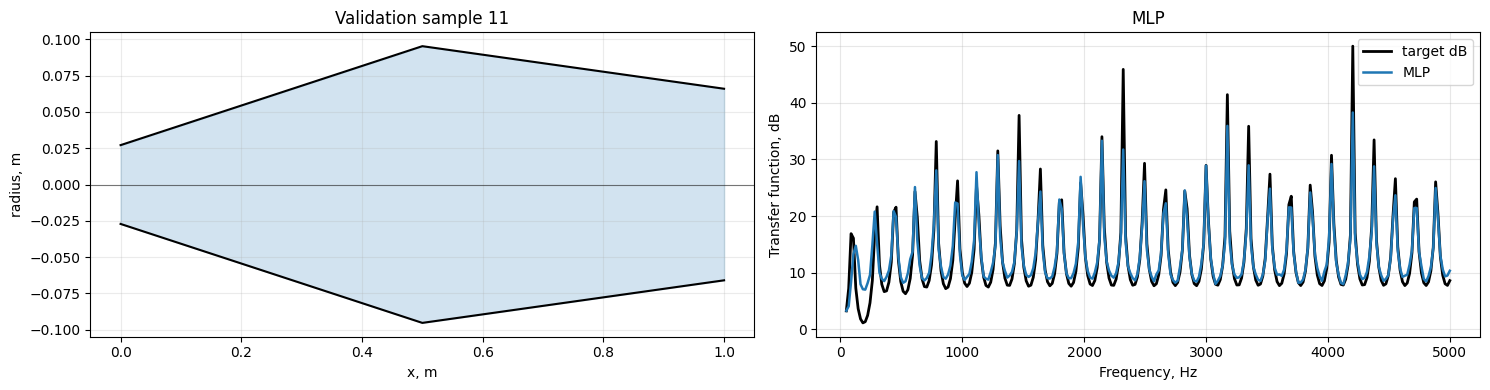

MLP MAE dB:  1.4403
MLP RMSE dB: 2.3207


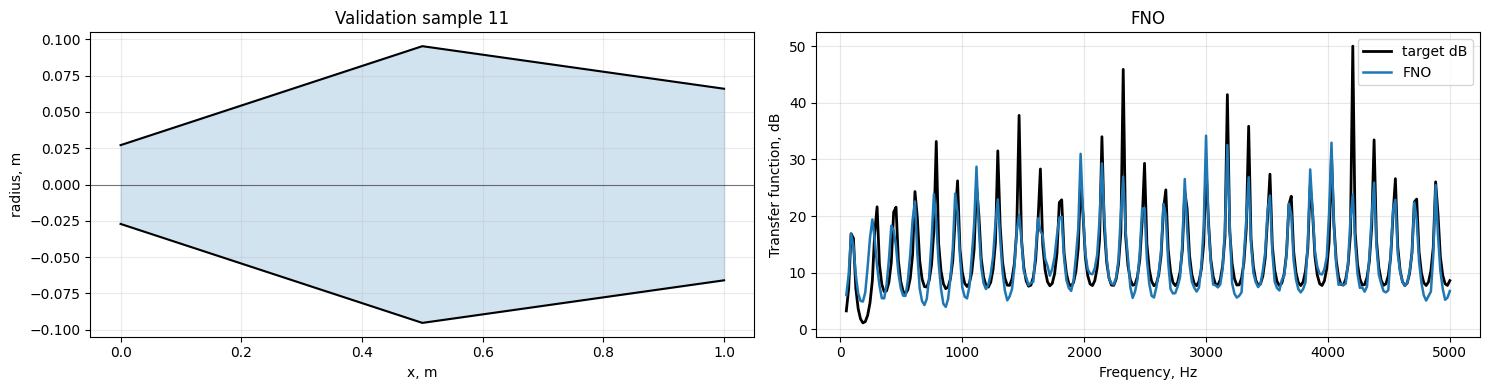

FNO MAE dB:  2.4208
FNO RMSE dB: 3.8394


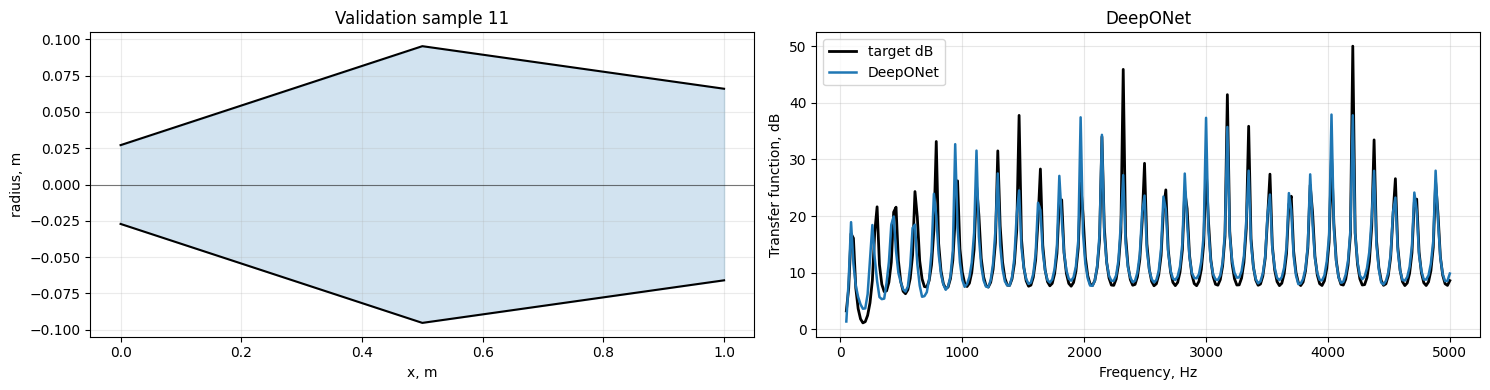

DeepONet MAE dB:  1.8664
DeepONet RMSE dB: 3.2645
=== Validation sample metrics ===
MLP      MAE dB:   1.4403 | RMSE dB:   2.3207
FNO      MAE dB:   2.4208 | RMSE dB:   3.8394
DeepONet MAE dB:   1.8664 | RMSE dB:   3.2645


In [28]:
mlp_checkpoint_name = "mlp_db"
fno_checkpoint_name = "fno_db_finetuned"
deeponet_checkpoint_name = "deeponet_db_finetuned_"
dynamic_deeponet_checkpoint_name = "dynamic_deeponet_db"
deformable_deeponet_checkpoint_name = "deformable_deeponet_db"

comparison_sample_idx = 11
comparison_batch = validation_preview_batch()


def checkpoint_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        return checkpoint["model_state"]
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint["state_dict"]
    return checkpoint


def checkpoint_history(checkpoint):
    if isinstance(checkpoint, dict):
        return checkpoint.get("history")
    return None


def make_mlp_for_comparison():
    return ProfileMLP(
        n_profile_points=n_profile_points,
        in_channels=2,
        n_frequencies=n_frequencies,
        hidden_dim=512,
        depth=4,
        dropout=0.05,
        out_channels=1,
    )


def make_fno_for_comparison():
    return TransferFunctionFNO(
        n_modes=32,
        hidden_channels=96,
        latent_dim=256,
        pooling_bins=16,
        frequency_bands=16,
        out_channels=1,
    )


def make_deeponet_for_comparison():
    return TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
    )


def make_dynamic_deeponet_for_comparison():
    return TransferFunctionDynamicDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
    )


def make_deformable_deeponet_for_comparison():
    return TransferFunctionDeformableDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        max_offset=2.0,
        offset_hidden_channels=32,
    )


def get_or_load_model(variable_name, checkpoint_name, factory, history_variable_name):
    existing_model = globals().get(variable_name)
    existing_history = globals().get(history_variable_name)

    if existing_model is not None:
        existing_model = existing_model.to(device)
        existing_model.eval()
        print(f"{variable_name}: using model from current notebook session")
        return existing_model, existing_history

    checkpoint_path = Path("checkpoints") / f"{checkpoint_name}_best.pt"
    if not checkpoint_path.exists():
        print(f"{variable_name}: checkpoint not found, skipping: {checkpoint_path}")
        return None, existing_history

    try:
        model = factory().to(device)
        checkpoint = torch.load(checkpoint_path, map_location=device)
        utils.load_model_state(model, checkpoint_state_dict(checkpoint), strict=True)
        model.eval()

        history = checkpoint_history(checkpoint)
        globals()[variable_name] = model
        if history is not None:
            globals()[history_variable_name] = history

        print(f"{variable_name}: loaded checkpoint {checkpoint_path}")
        if history is not None:
            print(f"{variable_name}: loaded training history from checkpoint")
        return model, history
    except Exception as exc:
        print(f"{variable_name}: failed to load checkpoint {checkpoint_path}: {exc}")
        return None, existing_history


model_specs = [
    (
        "MLP",
        "mlp",
        mlp_checkpoint_name,
        make_mlp_for_comparison,
        "mlp_history",
        mlp_batch_to_xy,
    ),
    (
        "FNO",
        "fno",
        fno_checkpoint_name,
        make_fno_for_comparison,
        "fno_history",
        fno_batch_to_xy,
    ),
    (
        "DeepONet",
        "deeponet",
        deeponet_checkpoint_name,
        make_deeponet_for_comparison,
        "deeponet_history",
        deeponet_batch_to_xy,
    ),
    (
        "Dynamic DeepONet",
        "dynamic_deeponet",
        dynamic_deeponet_checkpoint_name,
        make_dynamic_deeponet_for_comparison,
        "dynamic_deeponet_history",
        deeponet_batch_to_xy,
    ),
    (
        "Deformable DeepONet",
        "deformable_deeponet",
        deformable_deeponet_checkpoint_name,
        make_deformable_deeponet_for_comparison,
        "deformable_deeponet_history",
        deeponet_batch_to_xy,
    ),
]

models_to_compare = []
for label, variable_name, checkpoint_name, factory, history_name, batch_to_xy in model_specs:
    model, history = get_or_load_model(
        variable_name,
        checkpoint_name,
        factory,
        history_name,
    )
    models_to_compare.append((label, model, history, batch_to_xy))

# Target is available even if no model checkpoint exists.
_, target = mlp_batch_to_xy(comparison_batch, torch.device(device))
target = target.detach().cpu()

if comparison_sample_idx < 0 or comparison_sample_idx >= target.shape[0]:
    raise IndexError(
        f"comparison_sample_idx={comparison_sample_idx} is outside validation batch size {target.shape[0]}"
    )

predictions = {}
for name, model, _, batch_to_xy in models_to_compare:
    if model is None:
        continue
    prediction, _ = predict_on_batch(model, batch_to_xy, comparison_batch)
    predictions[name] = prediction
    plot_model_prediction_on_channel(
        comparison_batch,
        prediction,
        target,
        name,
        sample_idx=comparison_sample_idx,
    )

if not predictions:
    print("No trained models are available for comparison. Run training cells or add checkpoints.")
else:
    print("=== Validation sample metrics ===")
    y = target[comparison_sample_idx]
    for name, prediction in predictions.items():
        pred = prediction[comparison_sample_idx]
        mae = torch.mean(torch.abs(pred - y)).item()
        rmse = torch.sqrt(torch.mean((pred - y) ** 2)).item()
        print(f"{name:8s} MAE dB: {mae:8.4f} | RMSE dB: {rmse:8.4f}")


=== Loaded history lengths ===
MLP      train= 20 val= 20 train_steps= 200 val_steps= 200
FNO      train= 25 val= 25 train_steps= 250 val_steps= 250
DeepONet train= 35 val= 35 train_steps= 350 val_steps= 350


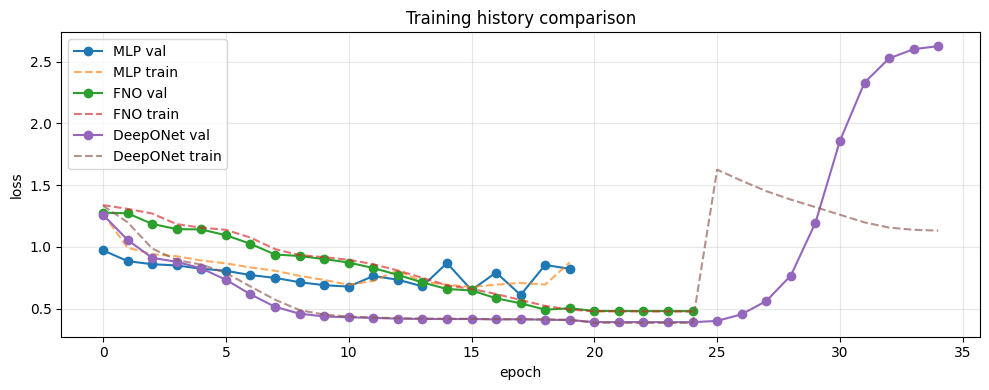

=== Best losses ===
MLP      best train loss: 0.6753780901432037 | best val loss: 0.610351276397705
FNO      best train loss: 0.4761244237422943 | best val loss: 0.47898716628551485
DeepONet best train loss: 0.38386406302452086 | best val loss: 0.38963031470775605


In [31]:
# Cell 11: compare training histories

def history_get(history, key):
    if history is None:
        return []
    if isinstance(history, dict):
        return history.get(key, []) or []
    return getattr(history, key, []) or []


def load_history_from_checkpoint(checkpoint_name):
    checkpoint_path = Path("checkpoints") / f"{checkpoint_name}_best.pt"
    if not checkpoint_path.exists():
        print(f"history checkpoint not found: {checkpoint_path}")
        return None

    try:
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
    except Exception as exc:
        print(f"failed to load history from {checkpoint_path}: {exc}")
        return None

    if isinstance(checkpoint, dict):
        history = checkpoint.get("history")
        if history is not None:
            return history

    print(f"checkpoint has no history: {checkpoint_path}")
    return None


def get_history(history_variable_name, checkpoint_name):
    history = globals().get(history_variable_name)
    if history is not None:
        return history

    history = load_history_from_checkpoint(checkpoint_name)
    if history is not None:
        globals()[history_variable_name] = history
    return history


history_specs = [
    ("MLP", get_history("mlp_history", mlp_checkpoint_name)),
    ("FNO", get_history("fno_history", fno_checkpoint_name)),
    ("DeepONet", get_history("deeponet_history", deeponet_checkpoint_name)),
    ("Dynamic DeepONet", get_history("dynamic_deeponet_history", dynamic_deeponet_checkpoint_name)),
    ("Deformable DeepONet", get_history("deformable_deeponet_history", deformable_deeponet_checkpoint_name)),
]

print("=== Loaded history lengths ===")
for name, history in history_specs:
    print(
        f"{name:8s} "
        f"train={len(history_get(history, 'train_loss')):3d} "
        f"val={len(history_get(history, 'val_loss')):3d} "
        f"train_steps={len(history_get(history, 'step_train_loss')):4d} "
        f"val_steps={len(history_get(history, 'step_val_loss')):4d}"
    )

available_histories = [
    (name, history)
    for name, history in history_specs
    if history_get(history, "train_loss") or history_get(history, "val_loss")
]

if not available_histories:
    print("No training histories are available. Run training cells or load checkpoints with history.")
else:
    plt.figure(figsize=(10, 4))

    for name, history in available_histories:
        val_loss = history_get(history, "val_loss")
        train_loss = history_get(history, "train_loss")
        if val_loss:
            plt.plot(val_loss, marker="o", label=f"{name} val")
        if train_loss:
            plt.plot(train_loss, linestyle="--", alpha=0.65, label=f"{name} train")

    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training history comparison")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("=== Best losses ===")
    for name, history in available_histories:
        val_loss = history_get(history, "val_loss")
        train_loss = history_get(history, "train_loss")
        best_train = min(train_loss) if train_loss else None
        best_val = min(val_loss) if val_loss else None
        print(f"{name:8s} best train loss: {best_train} | best val loss: {best_val}")


### Неожиданная геометрия

unexpected geometry: tube_with_hole
target shape: (1, 256)


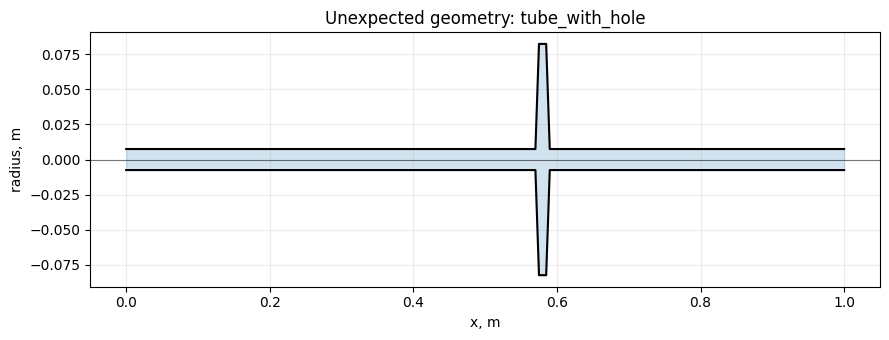

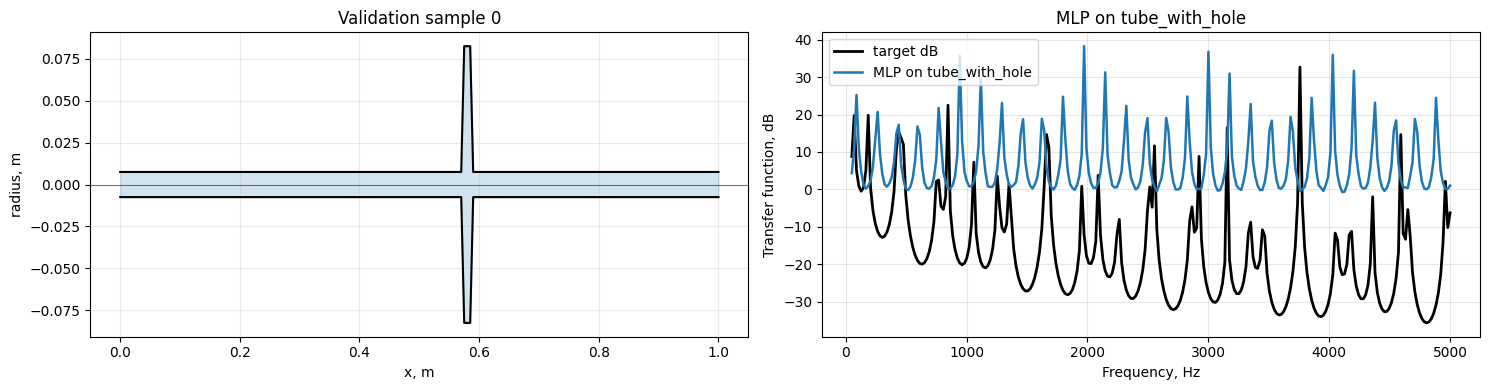

MLP on tube_with_hole MAE dB:  25.0911
MLP on tube_with_hole RMSE dB: 28.2239


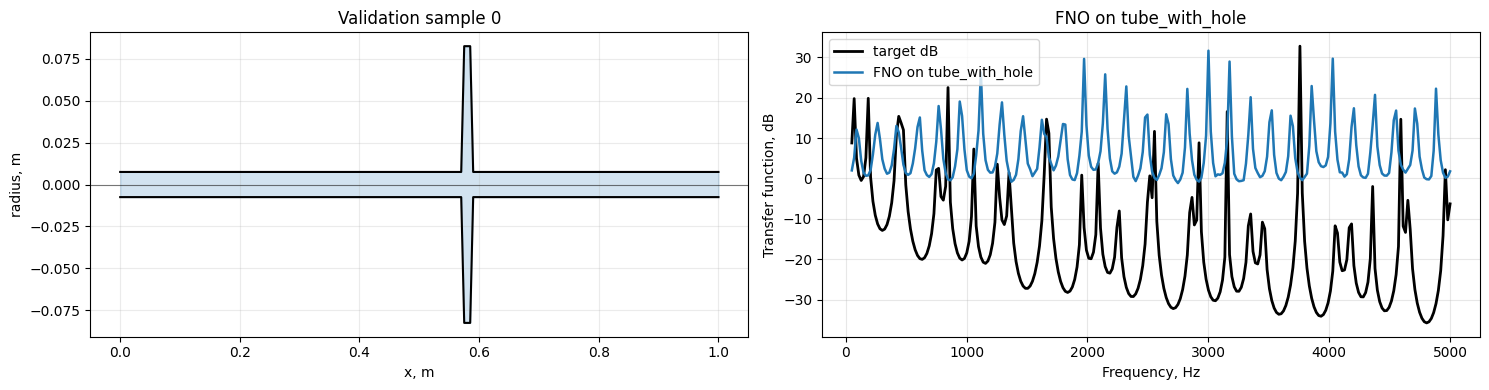

FNO on tube_with_hole MAE dB:  24.6331
FNO on tube_with_hole RMSE dB: 27.4872


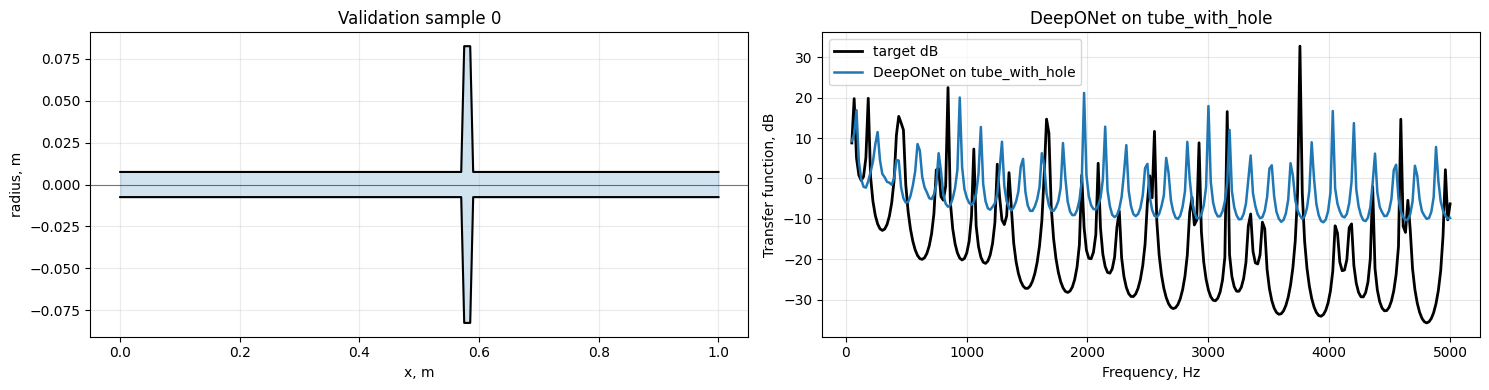

DeepONet on tube_with_hole MAE dB:  16.5896
DeepONet on tube_with_hole RMSE dB: 19.1615


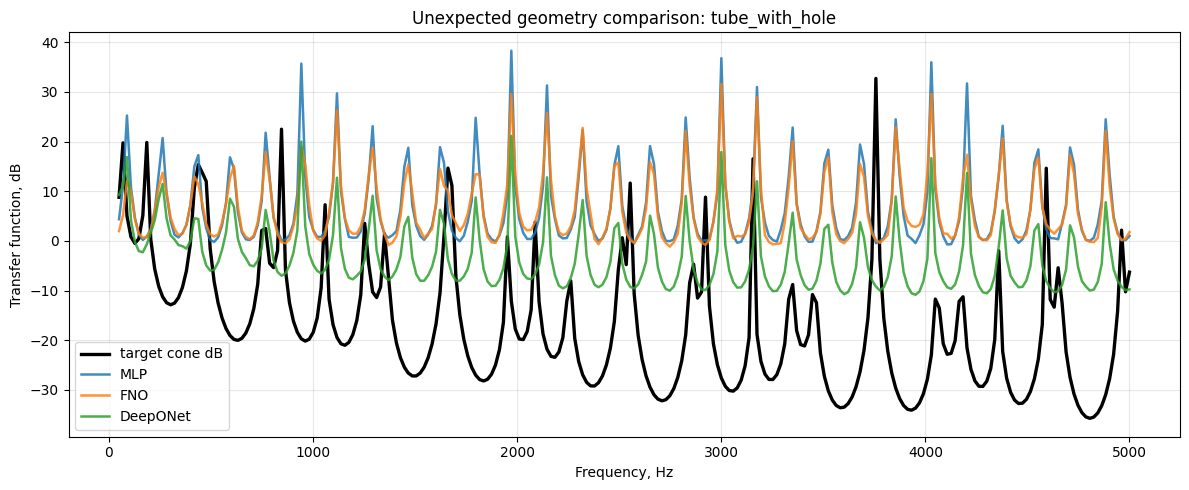

=== Unexpected geometry metrics ===
MLP      MAE dB:  25.0911 | RMSE dB:  28.2239
FNO      MAE dB:  24.6331 | RMSE dB:  27.4872
DeepONet MAE dB:  16.5896 | RMSE dB:  19.1615


In [32]:
# Cell 12: unexpected geometry check

unexpected_geometry_kind = "tube_with_hole"  # "tube_with_hole" or "sharp_bottleneck"


def make_unexpected_geometry(kind):
    if kind == "tube_with_hole":
        return vt.make_tube_with_hole_geometry(
            length_m=1.0,
            base_width_m=0.015,
            hole_center_m=0.58,
        )

    if kind == "sharp_bottleneck":
        return vt.explicit_geometry_from_arrays(
            x_m=[0.0, 0.18, 0.32, 0.50, 0.68, 0.82, 1.0],
            area_m2=[8.0e-4, 8.0e-4, 1.6e-4, 1.2e-4, 1.6e-4, 8.0e-4, 8.0e-4],
        )

    raise ValueError(f"Unsupported unexpected_geometry_kind: {kind!r}")


def make_single_geometry_batch(geometry, solver_config):
    result = vt.solve(
        geometry,
        config=solver_config,
    )

    target_db = 20.0 * torch.log10(
        torch.tensor(result.magnitude, dtype=torch.float32).clamp_min(1e-12)
    )

    x_m, area_m2, segment_lengths_m = vt.geometry_to_tube_tuple(geometry)

    batch = {
        "target": target_db.unsqueeze(0),
        "frequencies_hz": torch.tensor(result.frequencies_hz, dtype=torch.float32).unsqueeze(0),
        "geometry": {
            "x_m": torch.tensor([x_m], dtype=torch.float32),
            "area_m2": torch.tensor([area_m2], dtype=torch.float32),
            "segment_lengths_m": torch.tensor([segment_lengths_m], dtype=torch.float32),
            "node_count": torch.tensor([len(x_m)], dtype=torch.int64),
            "segment_count": torch.tensor([len(segment_lengths_m)], dtype=torch.int64),
        },
        "meta": [
            {
                "idx": 0,
                "seed": None,
                "solver": solver_config.solver,
                "geometry_kind_requested": unexpected_geometry_kind,
            }
        ],
    }

    return batch


def local_checkpoint_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        return checkpoint["model_state"]
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint["state_dict"]
    return checkpoint


def load_model_or_use_existing(variable_name, checkpoint_name, factory):
    model = globals().get(variable_name)
    if model is not None:
        model = model.to(device)
        model.eval()
        return model

    checkpoint_path = Path("checkpoints") / f"{checkpoint_name}_best.pt"
    if not checkpoint_path.exists():
        print(f"{variable_name}: checkpoint not found, skipping: {checkpoint_path}")
        return None

    try:
        model = factory().to(device)
        checkpoint = torch.load(checkpoint_path, map_location=device)
        utils.load_model_state(model, local_checkpoint_state_dict(checkpoint), strict=True)
        model.eval()
        globals()[variable_name] = model
        print(f"{variable_name}: loaded {checkpoint_path}")
        return model
    except Exception as exc:
        print(f"{variable_name}: failed to load {checkpoint_path}: {exc}")
        return None


def make_mlp_for_unexpected():
    return ProfileMLP(
        n_profile_points=n_profile_points,
        in_channels=2,
        n_frequencies=n_frequencies,
        hidden_dim=512,
        depth=4,
        dropout=0.05,
        out_channels=1,
    )


def make_fno_for_unexpected():
    return TransferFunctionFNO(
        n_modes=32,
        hidden_channels=96,
        latent_dim=256,
        pooling_bins=16,
        frequency_bands=16,
        out_channels=1,
    )


def make_deeponet_for_unexpected():
    return TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
    )


def make_dynamic_deeponet_for_unexpected():
    return TransferFunctionDynamicDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
    )


def make_deformable_deeponet_for_unexpected():
    return TransferFunctionDeformableDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        max_offset=2.0,
        offset_hidden_channels=32,
    )


unexpected_geometry = make_unexpected_geometry(unexpected_geometry_kind)
unexpected_batch = make_single_geometry_batch(unexpected_geometry, solver_config)

unexpected_models = [
    ("MLP", load_model_or_use_existing("mlp", mlp_checkpoint_name, make_mlp_for_unexpected), mlp_batch_to_xy),
    ("FNO", load_model_or_use_existing("fno", fno_checkpoint_name, make_fno_for_unexpected), fno_batch_to_xy),
    (
        "DeepONet",
        load_model_or_use_existing("deeponet", deeponet_checkpoint_name, make_deeponet_for_unexpected),
        deeponet_batch_to_xy,
    ),
    (
        "Dynamic DeepONet",
        load_model_or_use_existing("dynamic_deeponet", dynamic_deeponet_checkpoint_name, make_dynamic_deeponet_for_unexpected),
        deeponet_batch_to_xy,
    ),
    (
        "Deformable DeepONet",
        load_model_or_use_existing("deformable_deeponet", deformable_deeponet_checkpoint_name, make_deformable_deeponet_for_unexpected),
        deeponet_batch_to_xy,
    ),
]

_, unexpected_target = mlp_batch_to_xy(unexpected_batch, torch.device(device))
unexpected_target = unexpected_target.detach().cpu()

print("unexpected geometry:", unexpected_geometry_kind)
print("target shape:", tuple(unexpected_target.shape))

# Draw geometry once.
plt.figure(figsize=(9, 3.5))
ax = plt.gca()
plot_batch_geometry(
    unexpected_batch,
    0,
    ax,
    title=f"Unexpected geometry: {unexpected_geometry_kind}",
)
plt.tight_layout()
plt.show()

# Separate prediction plot for each available model.
unexpected_predictions = {}
for name, model, batch_to_xy in unexpected_models:
    if model is None:
        continue

    prediction, _ = predict_on_batch(model, batch_to_xy, unexpected_batch)
    unexpected_predictions[name] = prediction
    plot_model_prediction_on_channel(
        unexpected_batch,
        prediction,
        unexpected_target,
        f"{name} on {unexpected_geometry_kind}",
        sample_idx=0,
    )

# Combined plot for quick comparison.
if unexpected_predictions:
    freq = unexpected_batch["frequencies_hz"][0].detach().cpu()
    y = unexpected_target[0]

    plt.figure(figsize=(12, 5))
    plt.plot(freq, y, color="black", linewidth=2.4, label="target cone dB")
    for name, prediction in unexpected_predictions.items():
        plt.plot(freq, prediction[0], linewidth=1.8, alpha=0.85, label=name)

    plt.xlabel("Frequency, Hz")
    plt.ylabel("Transfer function, dB")
    plt.title(f"Unexpected geometry comparison: {unexpected_geometry_kind}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("=== Unexpected geometry metrics ===")
    for name, prediction in unexpected_predictions.items():
        pred = prediction[0]
        mae = torch.mean(torch.abs(pred - y)).item()
        rmse = torch.sqrt(torch.mean((pred - y) ** 2)).item()
        print(f"{name:8s} MAE dB: {mae:8.4f} | RMSE dB: {rmse:8.4f}")
else:
    print("No trained models are available for unexpected-geometry check.")
